In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix


In [2]:
file_path = '/kaggle/input/predict-ovarian-cancer/Supplementary data 1.xlsx'
df = pd.read_excel(file_path)
print("Data loaded successfully.")

# Drop SUBJECT_ID as done in the notebook
if 'SUBJECT_ID' in df.columns:
    df.drop('SUBJECT_ID', axis=1, inplace=True)

# Identify object columns among potential tumor markers
object_columns_in_markers = df[['AFP', 'CA125', 'CA19-9', 'CA72-4', 'CEA', 'HE4']].select_dtypes(include=['object']).columns.tolist()
print(f"Object columns to clean in markers: {object_columns_in_markers}")


Data loaded successfully.
Object columns to clean in markers: ['AFP', 'CA125', 'CA19-9']


In [3]:

# Using the cleaning function defined in the notebook
def clean_numeric_columns(df_in, columns):
    df_out = df_in.copy()
    
    def clean_value(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, (int, float)):
            return float(x)
        if isinstance(x, str):
            cleaned = re.sub(r'\\t|\s+', '', x)
            try:
                return float(cleaned)
            except ValueError:
                return np.nan
        return np.nan
    
    for col in columns:
        df_out[col] = df_out[col].apply(clean_value).astype(float)
    return df_out

df_cleaned = clean_numeric_columns(df, object_columns_in_markers)
print("Numeric columns cleaned.")


Numeric columns cleaned.


In [4]:

# Biomarker distribution settings
BIOMARKER_DISTRIBUTIONS = {
    'AFP': {'mean': 5, 'std': 2.5, 'units': 'ng/mL'},
    'CA125': {'mean': 17, 'std': 9, 'units': 'U/mL'},
    'CA19-9': {'mean': 18, 'std': 9.5, 'units': 'U/mL'},
    'CA72-4': {'mean': 3.5, 'std': 1.7, 'units': 'U/mL'},
    'HE4': {'mean': 70, 'std': 20, 'units': 'pmol/L'},
    'AG': {'mean': 12, 'std': 2, 'units': 'mEq/L'},
    'ALB': {'mean': 4.4, 'std': 0.5, 'units': 'g/dL'},
    'ALP': {'mean': 80, 'std': 30, 'units': 'IU/L'},
    'ALT': {'mean': 30, 'std': 12, 'units': 'IU/L'},
    'AST': {'mean': 28, 'std': 10, 'units': 'IU/L'},
    'CO2CP': {'mean': 26, 'std': 1.5, 'units': 'mEq/L'},
    'DBIL': {'mean': 0.15, 'std': 0.1, 'units': 'mg/dL'},
    'GGT': {'mean': 15, 'std': 7, 'units': 'U/L'},
    'GLO': {'mean': 2.9, 'std': 0.3, 'units': 'g/dL'},
    'IBIL': {'mean': 0.5, 'std': 0.2, 'units': 'mg/dL'},
    'MPV': {'mean': 9.5, 'std': 1, 'units': 'fL'},
    'NEU': {'mean': 4.75, 'std': 1.5, 'units': '10^3/μL'},
    'PCT': {'mean': 0.1, 'std': 0.2, 'units': 'ng/mL'},
    'PDW': {'mean': 13, 'std': 2, 'units': '%'},
    'TBIL': {'mean': 0.75, 'std': 0.3, 'units': 'mg/dL'},
    'TP': {'mean': 7.15, 'std': 0.5, 'units': 'g/dL'}
}

def generate_biomarker_imputation(df_in, biomarkers=None, seed=42):
    imputed_df_out = df_in.copy()
    np.random.seed(seed)
    
    if biomarkers is None:
        biomarkers = list(BIOMARKER_DISTRIBUTIONS.keys())
    
    imputation_details_out = {}
    
    for marker in biomarkers:
        if marker not in imputed_df_out.columns or not imputed_df_out[marker].isna().any():
            continue
        
        dist_params = BIOMARKER_DISTRIBUTIONS[marker]
        missing_mask = imputed_df_out[marker].isna()
        n_missing = missing_mask.sum()
        
        impute_values = np.random.normal(
            loc=dist_params['mean'],
            scale=dist_params['std'],
            size=n_missing
        )
        impute_values[impute_values < 0] = 0  # Ensure non-negative
        imputed_df_out.loc[missing_mask, marker] = impute_values
        
        imputation_details_out[marker] = {
            'n_imputed': n_missing,
            'imputation_mean': dist_params['mean'],
            'imputation_std': dist_params['std'],
            'units': dist_params['units']
        }
    
    return imputed_df_out, imputation_details_out

# Define the tumor marker columns
tumor_markers = ['AFP', 'CA125', 'CA19-9', 'CA72-4', 'CEA', 'HE4']

# Impute missing values only for tumor markers defined in BIOMARKER_DISTRIBUTIONS
markers_to_impute = [m for m in tumor_markers if m in BIOMARKER_DISTRIBUTIONS and df_cleaned[m].isnull().any()]
df_imputed, details = generate_biomarker_imputation(df_cleaned, biomarkers=markers_to_impute)
print("Imputation details (Normal Distribution):", details)

# Impute remaining NaNs in tumor markers (like CEA if not in distributions) with mean
for col in tumor_markers:
    if df_imputed[col].isnull().any():
        mean_val = df_imputed[col].mean()
        df_imputed[col].fillna(mean_val, inplace=True)
        print(f"Filled remaining NaNs in '{col}' with mean: {mean_val:.4f}")


Imputation details (Normal Distribution): {'AFP': {'n_imputed': 24, 'imputation_mean': 5, 'imputation_std': 2.5, 'units': 'ng/mL'}, 'CA125': {'n_imputed': 19, 'imputation_mean': 17, 'imputation_std': 9, 'units': 'U/mL'}, 'CA19-9': {'n_imputed': 34, 'imputation_mean': 18, 'imputation_std': 9.5, 'units': 'U/mL'}, 'CA72-4': {'n_imputed': 240, 'imputation_mean': 3.5, 'imputation_std': 1.7, 'units': 'U/mL'}, 'HE4': {'n_imputed': 20, 'imputation_mean': 70, 'imputation_std': 20, 'units': 'pmol/L'}}
Filled remaining NaNs in 'CEA' with mean: 3.3091


/tmp/ipykernel_36/2085174617.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(mean_val, inplace=True)


In [5]:
X = df_imputed[tumor_markers]
y = df_imputed['TYPE']  # Target variable

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Class distribution:\n", y.value_counts())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled.")



Feature matrix shape: (349, 6)
Target vector shape: (349,)
Class distribution:
 TYPE
1    178
0    171
Name: count, dtype: int64
Features scaled.


In [6]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

# Compute scale_pos_weight to handle imbalance (negatives/positives in y_train)
neg, pos = y_train.value_counts().loc[0], y_train.value_counts().loc[1]
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

scale_pos_weight = 0.96


In [8]:
xgb_model = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

print("\nTraining XGBoost model on Tumor Markers...")
xgb_model.fit(X_train_scaled, y_train)


Training XGBoost model on Tumor Markers...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [9]:
y_pred = xgb_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8857142857142857
Balanced Accuracy: 0.886437908496732

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.89        34
           1       0.91      0.86      0.89        36

    accuracy                           0.89        70
   macro avg       0.89      0.89      0.89        70
weighted avg       0.89      0.89      0.89        70



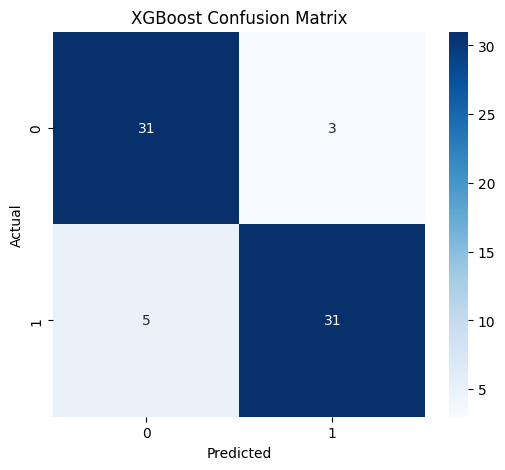

In [10]:

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()